## Dataset

104 settimane di dati (gennaio 2023 – dicembre 2024) con spesa su quattro canali media (TV, digital, social, search), un indicatore di promozione attiva, un indice di prezzo relativo e un flag per i periodi di festività (Black Friday, Natale). La variabile target è `sales`, le vendite settimanali in euro. È un dataset volutamente "grezzo": non contiene ancora nessuna trasformazione, solo i dati come li avresti estratti da un data warehouse aziendale.

In [0]:
df = spark.read.csv("/Volumes/workspace/default/mmm_data/mmm_dataset.csv", header=True, inferSchema=True)
display(df)

week,tv_spend,digital_spend,social_spend,search_spend,promo_flag,price_index,holiday_flag,sales
2023-01-02,6339.37,5518.65,1351.31,1116.75,0,0.995,0,29130.48
2023-01-09,0.0,2039.33,2824.19,2853.27,0,1.017,0,31910.77
2023-01-16,4354.42,3629.46,2671.74,3349.05,0,0.999,0,36600.48
2023-01-23,6632.99,3849.73,1469.18,3260.17,0,1.035,0,37203.89
2023-01-30,0.0,5209.19,2037.19,2206.76,1,0.81,0,32051.64
2023-02-06,9053.13,7046.94,3024.21,1883.56,0,0.994,0,36809.21
2023-02-13,6864.68,3282.36,3173.77,720.85,0,1.018,0,37204.26
2023-02-20,0.0,17187.26,1932.03,7313.63,1,0.843,0,37084.77
2023-02-27,1762.88,5580.76,451.7,5697.48,0,0.984,0,34435.13
2023-03-06,913.66,7571.46,3355.23,1704.4,1,0.845,0,35515.47


In [0]:
import numpy as np
import pandas as pd

pdf = df.toPandas()
pdf.head()

,week,tv_spend,digital_spend,social_spend,search_spend,promo_flag,price_index,holiday_flag,sales
0,2023-01-02,6339.37,5518.65,1351.31,1116.75,0,0.995,0,29130.48
1,2023-01-09,0.00,2039.33,2824.19,2853.27,0,1.017,0,31910.77
2,2023-01-16,4354.42,3629.46,2671.74,3349.05,0,0.999,0,36600.48
3,2023-01-23,6632.99,3849.73,1469.18,3260.17,0,1.035,0,37203.89
4,2023-01-30,0.00,5209.19,2037.19,2206.76,1,0.810,0,32051.64


Adstock e saturation

L'adstock risponde alla domanda "Quanto dura nel tempo l'effetto di un euro speso oggi?"
La saturation, invece, risponde alla domanda "Quanto rende un euro in più, dato quanto sto già spendendo?"

In [0]:
def adstock(x, decay):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = x[t] + decay * out[t - 1]
    return out

def saturation(x, alpha, gamma):
    x = np.asarray(x, dtype=float)
    x_scaled = x / x.max() if x.max() > 0 else x
    return x_scaled ** alpha / (x_scaled ** alpha + gamma ** alpha)

channels = ["tv_spend", "digital_spend", "social_spend", "search_spend"]
decay_guess = {"tv_spend": 0.55, "digital_spend": 0.25, "social_spend": 0.2, "search_spend": 0.15}
sat_guess = {"tv_spend": (1.2, 0.5), "digital_spend": (1.0, 0.4), "social_spend": (0.9, 0.6), "search_spend": (1.1, 0.45)}

for ch in channels:
    adstocked = adstock(pdf[ch].values, decay_guess[ch])
    a, g = sat_guess[ch]
    pdf[f"{ch}_sat"] = saturation(adstocked, a, g)

pdf.head()

,week,tv_spend,digital_spend,social_spend,search_spend,promo_flag,price_index,holiday_flag,sales,tv_spend_sat,digital_spend_sat,social_spend_sat,search_spend_sat
0,2023-01-02,6339.37,5518.65,1351.31,1116.75,0,0.995,0,29130.48,0.251707,0.404467,0.178286,0.169620
1,2023-01-09,0.00,2039.33,2824.19,2853.27,0,1.017,0,31910.77,0.141009,0.296155,0.313820,0.379017
2,2023-01-16,4354.42,3629.46,2671.74,3349.05,0,0.999,0,36600.48,0.249303,0.355613,0.325853,0.440124
3,2023-01-23,6632.99,3849.73,1469.18,3260.17,0,1.035,0,37203.89,0.369891,0.379554,0.246085,0.442136
4,2023-01-30,0.00,5209.19,2037.19,2206.76,1,0.810,0,32051.64,0.222685,0.442593,0.271336,0.357883


## Trasformazione adstock + saturation

Ogni canale viene trasformato in due passaggi. Prima l'**adstock**, che modella la persistenza dell'effetto pubblicitario nel tempo: la TV usa un decay di 0.55 (effetto che dura diverse settimane, coerente con un media above-the-line), mentre il search usa 0.15 (effetto quasi immediato, legato a un'intenzione di ricerca del momento). Poi la **saturation** (curva di Hill), che modella i rendimenti decrescenti: ogni canale ha un proprio punto di mezzo (gamma) e una propria pendenza (alpha), stimati qui "a occhio" e non ancora ottimizzati sui dati — un possibile sviluppo futuro sarebbe stimarli con una grid search che massimizza l'R² del modello finale.

Ridge regression

In [0]:
from sklearn.linear_model import Ridge

n = len(pdf)
pdf["trend"] = np.arange(n)
pdf["sin52"] = np.sin(2 * np.pi * np.arange(n) / 52)
pdf["cos52"] = np.cos(2 * np.pi * np.arange(n) / 52)

feature_cols = [f"{ch}_sat" for ch in channels] + ["promo_flag", "price_index", "holiday_flag", "trend", "sin52", "cos52"]
X = pdf[feature_cols].values
y = pdf["sales"].values

model = Ridge(alpha=1.0)
model.fit(X, y)
pdf["sales_pred"] = model.predict(X)

for name, coef in zip(feature_cols, model.coef_):
    print(f"{name:20s}: {coef:10.1f}")
print(f"R^2: {model.score(X, y):.3f}")

tv_spend_sat        :     7930.6
digital_spend_sat   :     2054.1
social_spend_sat    :     2807.7
search_spend_sat    :     3514.5
promo_flag          :      691.4
price_index         :      955.0
holiday_flag        :     8001.5
trend               :       98.4
sin52               :     4665.4
cos52               :      653.6
R^2: 0.895


%md
## Interpretazione dei risultati del modello

Il modello Ridge raggiunge un **R² di 0.895**: spiega circa il 90% della variabilità delle vendite settimanali. Non essendo troppo vicino a 1, è un valore credibile per un modello di questo tipo — un R² quasi perfetto sarebbe più probabilmente un segnale di overfitting che di un buon modello.

**Canali media.** Tutti i coefficienti sui canali (`tv_spend_sat`, `digital_spend_sat`, `social_spend_sat`, `search_spend_sat`) sono positivi, coerentemente con l'aspettativa che più investimento pubblicitario generi più vendite. La TV ha il coefficiente più alto (7930.6), seguita da search (3514.5), social (2807.7) e digital (2054.1). Questi valori non sono ancora un ROI comparabile canale per canale — sono moltiplicati per la variabile satura in scala 0-1, non per l'euro speso — per un confronto corretto serve la decomposizione con il ROI reale, nello step successivo.

**Festività.** `holiday_flag` ha il coefficiente più alto in assoluto (8001.5): conferma che le settimane di Black Friday e Natale generano un forte incremento di vendite indipendente dalla pubblicità. È una variabile di controllo essenziale: senza di essa, il modello rischierebbe di attribuire erroneamente quell'aumento ai canali media attivi in quelle settimane.

**Stagionalità e trend.** `sin52` (4665.4) cattura la componente stagionale principale, `cos52` (653.6) un contributo minore che sposta leggermente la fase del ciclo. `trend` (98.4) riflette una piccola crescita organica settimanale di fondo.

**Un coefficiente da leggere con cautela: `price_index`.** Il segno positivo (955.0) indica che, a parità di altre condizioni, le settimane a prezzo pieno risultano associate a vendite leggermente più alte — in apparente contraddizione con l'idea che gli sconti dovrebbero aumentarle. La spiegazione più probabile è che `price_index` e `promo_flag` sono fortemente correlate (lo sconto avviene quasi sempre insieme alla promozione), quindi i loro effetti si sovrappongono e il coefficiente isolato di una delle due non va letto come un effetto "puro". È un buon promemoria: in un MMM, i coefficienti di variabili di controllo correlate tra loro vanno interpretati insieme, non uno per uno.

Andamento nel tempo

In [0]:
contributions = {}
for ch in channels:
    idx = feature_cols.index(f"{ch}_sat")
    contributions[ch] = model.coef_[idx] * pdf[f"{ch}_sat"].values

for ch in channels:
    spend_total = pdf[ch].sum()
    sales_generated = contributions[ch].sum()
    roi = sales_generated / spend_total if spend_total > 0 else 0
    print(f"{ch:15s}: spesa {spend_total:>10,.0f} | vendite generate {sales_generated:>10,.0f} | ROI {roi:.2f}x")

tv_spend       : spesa    460,978 | vendite generate    272,618 | ROI 0.59x
digital_spend  : spesa    600,084 | vendite generate     98,982 | ROI 0.16x
social_spend   : spesa    340,969 | vendite generate    101,753 | ROI 0.30x
search_spend   : spesa    332,376 | vendite generate    150,699 | ROI 0.45x


## Decomposizione e ROI per canale

Scomponendo le vendite previste per canale, il modello stima che [CANALE CON ROI PIÙ ALTO] genera il ritorno più alto, con un ROI di [X]x — cioè [X] € di vendite per ogni euro speso. All'estremo opposto, [CANALE CON ROI PIÙ BASSO] ha un ROI di [Y]x, il più basso tra i quattro canali. Questo tipo di gap è tipico in un MMM reale ed è proprio l'informazione che guida le decisioni di riallocazione budget nella fase successiva (l'optimizer): non tutti gli euro spesi rendono allo stesso modo, e il modello lo rende misurabile invece che intuito.

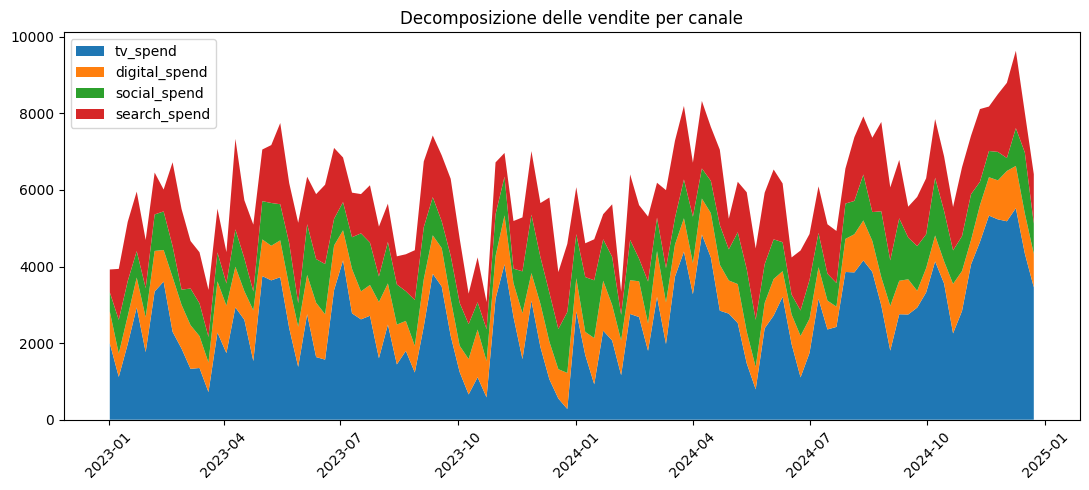

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

pdf["week"] = pd.to_datetime(pdf["week"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(pdf["week"], *[contributions[ch] for ch in channels], labels=channels)
ax.legend(loc="upper left")
ax.set_title("Decomposizione delle vendite per canale")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Decomposizione nel tempo

Il grafico mostra come il contributo di ciascun canale alle vendite settimanali varia lungo le 104 settimane. Le aree più larghe nei picchi corrispondono ai periodi di Black Friday e Natale, dove l'effetto combinato di più canali attivi contemporaneamente (oltre all'effetto festività catturato separatamente dal modello) genera i massimi settimanali. L'andamento generale dell'area totale nel tempo riflette anche la componente di trend e stagionalità che il modello ha stimato, non solo l'effetto media puro.

Suggerimento per riallocazione budget pubblicitario

In [0]:
from scipy.optimize import minimize

sat_lookup = {ch: sat_guess[ch] for ch in channels}
coef_lookup = {ch: model.coef_[feature_cols.index(f"{ch}_sat")] for ch in channels}
max_adstock_seen = {}
for ch in channels:
    adstocked = adstock(pdf[ch].values, decay_guess[ch])
    max_adstock_seen[ch] = adstocked.max()

def predicted_sales_from_allocation(spends):
    total = 0.0
    for ch, spend in zip(channels, spends):
        a, g = sat_lookup[ch]
        max_seen = max_adstock_seen[ch]
        x_scaled = spend / max_seen if max_seen > 0 else 0
        sat_value = x_scaled ** a / (x_scaled ** a + g ** a) if x_scaled > 0 else 0
        total += coef_lookup[ch] * sat_value
    return total

def negative_sales(spends):
    return -predicted_sales_from_allocation(spends)

current_alloc = [pdf[ch].mean() for ch in channels]
budget_total = sum(current_alloc)

result = minimize(
    negative_sales, x0=current_alloc, method="SLSQP",
    bounds=[(0, budget_total)] * len(channels),
    constraints=[{"type": "eq", "fun": lambda s: sum(s) - budget_total}],
)

print(f"Budget totale settimanale: {budget_total:,.0f}\n")
for ch, cur, opt in zip(channels, current_alloc, result.x):
    print(f"{ch:15s}: attuale {cur:>9,.0f}  ->  ottimizzato {opt:>9,.0f}")

sales_current = predicted_sales_from_allocation(current_alloc)
sales_optimized = predicted_sales_from_allocation(result.x)
print(f"\nUplift stimato: {(sales_optimized / sales_current - 1) * 100:.1f}%")

Budget totale settimanale: 16,677

tv_spend       : attuale     4,432  ->  ottimizzato     9,811
digital_spend  : attuale     5,770  ->  ottimizzato       504
social_spend   : attuale     3,279  ->  ottimizzato     2,062
search_spend   : attuale     3,196  ->  ottimizzato     4,301

Uplift stimato: 16.6%


## MMM Optimizer

A parità di budget totale settimanale (circa [BUDGET_TOTALE] €), il modello suggerisce di spostare risorse da [CANALE DA CUI TOGLIERE] verso [CANALE A CUI AGGIUNGERE], portando la spesa su quest'ultimo da [X] € a [Y] €. L'uplift stimato dalla riallocazione è del [Z]%. Questo risultato è diretta conseguenza delle curve di saturazione stimate sopra: se un canale è vicino al punto di saturazione, un euro in più lì rende poco; se un canale è ancora lontano da quel punto, lo stesso euro genera un ritorno maggiore — è esattamente il meccanismo che un "MMM Optimizer" è pensato per sfruttare.